# DreamCoder Train/Test Pipeline – Schritt für Schritt

Dieses Notebook führt die Pipeline **nicht als ein großes `run_all.sh`** aus, sondern jeden Schritt einzeln. Nach jedem Schritt kannst du die erzeugten Dateien prüfen, bevor du weitergehst.

Wichtig: Dieses Notebook muss im Ordner `dreamcoder_train_test_pipeline_step_by_step` oder `dreamcoder_train_test_pipeline_robust` liegen und mit dem Kernel `Python (dreamcoder)` ausgeführt werden.


In [1]:
from pathlib import Path
import os, subprocess, json, pandas as pd, textwrap

ROOT = Path.cwd()
print("Current folder:", ROOT)
print("Files:", sorted([p.name for p in ROOT.iterdir()]))

assert (ROOT / "scripts").exists(), "Der Ordner scripts fehlt. Öffne das Notebook im Pipeline-Hauptordner."
assert (ROOT / "dataset").exists(), "Der Ordner dataset fehlt."


Current folder: /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step
Files: ['.ipynb_checkpoints', 'DreamCoder_Train_Test_Workflow.ipynb', 'NOTEBOOK_STEP_BY_STEP.md', 'README.md', 'dataset', 'outputs', 'run_all.sh', 'scripts']


## 0. Konfiguration

Hier stellst du ein, welcher Train-/Test-Datensatz benutzt wird und wie stark DreamCoder suchen soll.


In [2]:
TRAIN_DATASET_FILE = "dataset/T=2_train.json"
TEST_DATASET_FILE = "dataset/T=2_test.json"
DREAMCODER_REPO_ROOT = "/mnt/c/BA/ec"
PYTHON = "/root/miniconda3/envs/dreamcoder/bin/python"

# Erst klein testen. Danach kannst du diese Werte erhöhen.
MAX_TRAIN_TASKS = 150
DREAMCODER_TIMEOUT = 10
DREAMCODER_TESTING_TIMEOUT = 10
DREAMCODER_ITERATIONS = 2
DREAMCODER_FRONTIER_SIZE = 20
DREAMCODER_USE_RECOGNITION = "false"
DREAMCODER_NO_CONSOLIDATION = "false"
DREAMCODER_CPUS = 1

train_path = ROOT / TRAIN_DATASET_FILE
test_path = ROOT / TEST_DATASET_FILE
print("Train:", train_path, train_path.exists())
print("Test :", test_path, test_path.exists())

if not train_path.exists():
    print("FEHLT:", train_path)
    print("Kopiere z. B. im Terminal:")
    print(f"cp /mnt/c/BA/deepcoder/dataset/T=2_train.json {train_path}")

assert test_path.exists(), "Testdatensatz fehlt."
assert train_path.exists(), "Trainingsdatensatz fehlt."


Train: /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/dataset/T=2_train.json True
Test : /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/dataset/T=2_test.json True


## 0.1 Output-Ordner erzeugen

Alle Ergebnisse dieses Laufs werden in `outputs/<RUN_KEY>/` gespeichert.


In [3]:
def sanitize(name: str) -> str:
    return Path(name).stem.replace("=", "_").replace(".", "_").replace("-", "_")

TRAIN_KEY = sanitize(TRAIN_DATASET_FILE)
TEST_KEY = sanitize(TEST_DATASET_FILE)
RUN_KEY = (
    f"train_{TRAIN_KEY}__test_{TEST_KEY}__"
    f"ET_{DREAMCODER_TIMEOUT}_TT_{DREAMCODER_TESTING_TIMEOUT}_"
    f"it_{DREAMCODER_ITERATIONS}_MF_{DREAMCODER_FRONTIER_SIZE}_"
    f"rec_{DREAMCODER_USE_RECOGNITION}_nocons_{DREAMCODER_NO_CONSOLIDATION}"
)
OUTPUT_ROOT = ROOT / "outputs" / RUN_KEY
LOG_DIR = OUTPUT_ROOT / "logs"

step_dirs = [
    "step01_validate_datasets",
    "step02_convert_train_test",
    "step03_create_task_pickles",
    "step04_run_dreamcoder",
    "step05_detect_operations",
    "step06_normalize_programs",
    "step07_calculate_metrics",
    "step08_summarize_results",
]
for d in step_dirs:
    (OUTPUT_ROOT / d).mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("RUN_KEY:", RUN_KEY)
print("OUTPUT_ROOT:", OUTPUT_ROOT)


RUN_KEY: train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false
OUTPUT_ROOT: /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false


## Hilfsfunktion zum Ausführen eines Schritts


In [4]:
def run_step(name, cmd, log_name=None):
    log_name = log_name or f"{name}.log"
    log_path = LOG_DIR / log_name
    print("\n" + "="*80)
    print(name)
    print("Command:", " ".join(map(str, cmd)))
    print("Log:", log_path)
    print("="*80 + "\n")
    with open(log_path, "w", encoding="utf-8") as f:
        process = subprocess.Popen(
            list(map(str, cmd)),
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        for line in process.stdout:
            print(line, end="")
            f.write(line)
        rc = process.wait()
    print("\nReturn code:", rc)
    if rc != 0:
        raise RuntimeError(f"{name} failed with return code {rc}")
    return log_path


## Schritt 1 – Datensätze validieren

Prüft Anzahl Aufgaben, Beispiele, Output-Typen, Null-Outputs usw.

Ergebnisse: `step01_validate_datasets/`


In [5]:
run_step("step01_validate_datasets", [
    PYTHON,
    ROOT / "scripts" / "step01_validate_datasets.py",
    train_path,
    test_path,
    OUTPUT_ROOT / "step01_validate_datasets",
])

print("\nErzeugte Dateien:")
for p in sorted((OUTPUT_ROOT / "step01_validate_datasets").iterdir()): print(p)



step01_validate_datasets
Command: /root/miniconda3/envs/dreamcoder/bin/python /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/scripts/step01_validate_datasets.py /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/dataset/T=2_train.json /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/dataset/T=2_test.json /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step01_validate_datasets
Log: /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/logs/step01_validate_datasets.log

{
  "train": {
    "path": "/mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/dataset/T=2_train.json",
    "tasks": 2365,
    "program_length_min": 2,
    "program_length_max": 2,
    "examples_per_task_min": 5,
    "examples_per_task_max": 5,
    "null_outputs": 175,
    "tasks_with_only_null_outputs": 26,
  

## Schritt 2 – Train/Test-Aufgaben konvertieren

Konvertiert JSON-Aufgaben in ein Zwischenformat mit Task-Namen, Request-Typen, Beispielen und Referenzprogrammen.

Ergebnisse: `step02_convert_train_test/`


In [6]:
run_step("step02_convert_train_test_tasks", [
    PYTHON,
    ROOT / "scripts" / "step02_convert_train_test_tasks.py",
    train_path,
    test_path,
    OUTPUT_ROOT / "step02_convert_train_test",
    MAX_TRAIN_TASKS,
])

print("\nErzeugte Dateien:")
for p in sorted((OUTPUT_ROOT / "step02_convert_train_test").iterdir()): print(p)



step02_convert_train_test_tasks
Command: /root/miniconda3/envs/dreamcoder/bin/python /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/scripts/step02_convert_train_test_tasks.py /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/dataset/T=2_train.json /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/dataset/T=2_test.json /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step02_convert_train_test 150
Log: /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/logs/step02_convert_train_test_tasks.log

{
  "train_tasks": 150,
  "test_tasks": 99,
  "skipped_tasks": 1,
  "max_train_tasks": 150,
  "train_json": "/mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step02_convert_train_test/step02_train_t

## Schritt 3 – DreamCoder Task-Pickles erzeugen

Erzeugt echte DreamCoder-`Task`-Objekte für Training und Test.

Ergebnisse: `step03_create_task_pickles/`


In [7]:
run_step("step03_create_dreamcoder_task_pickles", [
    PYTHON,
    ROOT / "scripts" / "step03_create_dreamcoder_task_pickles.py",
    OUTPUT_ROOT / "step02_convert_train_test" / "step02_train_tasks.json",
    OUTPUT_ROOT / "step02_convert_train_test" / "step02_test_tasks.json",
    OUTPUT_ROOT / "step03_create_task_pickles",
    DREAMCODER_REPO_ROOT,
])

print("\nErzeugte Dateien:")
for p in sorted((OUTPUT_ROOT / "step03_create_task_pickles").iterdir()): print(p)



step03_create_dreamcoder_task_pickles
Command: /root/miniconda3/envs/dreamcoder/bin/python /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/scripts/step03_create_dreamcoder_task_pickles.py /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step02_convert_train_test/step02_train_tasks.json /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step02_convert_train_test/step02_test_tasks.json /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step03_create_task_pickles /mnt/c/BA/ec
Log: /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/logs/step03_create_dreamcoder_task_pickles.log

Created DreamCoder Task objects
Train 

## Schritt 4 – DreamCoder Training/Test ausführen

Das ist der rechenintensive Schritt. DreamCoder sucht Programme für Trainings- und Testaufgaben. Die robuste Version speichert auch `step04_stdout.log` und extrahiert Test-HITs aus dem stdout, falls die Test-Frontiers nicht im Ergebnisobjekt stehen.

Ergebnisse: `step04_run_dreamcoder/`


In [8]:
run_step("step04_run_dreamcoder_train_test", [
    PYTHON,
    ROOT / "scripts" / "step04_run_dreamcoder_train_test.py",
    OUTPUT_ROOT / "step03_create_task_pickles" / "step03_train_tasks.pkl",
    OUTPUT_ROOT / "step03_create_task_pickles" / "step03_test_tasks.pkl",
    OUTPUT_ROOT / "step02_convert_train_test" / "step02_train_tasks.json",
    OUTPUT_ROOT / "step02_convert_train_test" / "step02_test_tasks.json",
    OUTPUT_ROOT / "step04_run_dreamcoder",
    DREAMCODER_REPO_ROOT,
    DREAMCODER_TIMEOUT,
    DREAMCODER_TESTING_TIMEOUT,
    DREAMCODER_ITERATIONS,
    DREAMCODER_FRONTIER_SIZE,
    DREAMCODER_USE_RECOGNITION,
    DREAMCODER_NO_CONSOLIDATION,
    DREAMCODER_CPUS,
])

print("\nErzeugte Dateien:")
for p in sorted((OUTPUT_ROOT / "step04_run_dreamcoder").iterdir()): print(p)



step04_run_dreamcoder_train_test
Command: /root/miniconda3/envs/dreamcoder/bin/python /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/scripts/step04_run_dreamcoder_train_test.py /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step03_create_task_pickles/step03_train_tasks.pkl /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step03_create_task_pickles/step03_test_tasks.pkl /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step02_convert_train_test/step02_train_tasks.json /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step02_convert_train_test/step02_test_tasks.json /mnt/c/BA/ec/dreamcoder_train_test_pipelin

In [9]:
from pathlib import Path

log_path = LOG_DIR / "step04_run_dreamcoder_train_test.log"

print("Log-Datei:", log_path)
print("=" * 80)

text = log_path.read_text(encoding="utf-8", errors="replace")
print("\n".join(text.splitlines()[-120:]))

Log-Datei: /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/logs/step04_run_dreamcoder_train_test.log
-0.165218	(lambda (#(index 0) (sort $0)))
-2.327304	(lambda (#(index 0) (sort (sort $0))))
-3.051272	(lambda (#(index 0) (sort (reverse $0))))
-5.032962	(lambda (index (negate 0) (sort $0)))
-7.746252	(lambda (* (#(index 0) (sort $0)) 1))
-7.746252	(lambda (* 1 (#(index 0) (sort $0))))
-9.906483	(lambda (index (sum empty) (sort $0)))
train_task_00041__LIST_FILTER_<0_0_ZIPWITH_max_1_1
-0.013092	(lambda (#(filter (lambda (gt? 0 $0))) $0))
-5.786960	(lambda (filter (lambda (gt? 1 $0)) $0))
-5.997592	(lambda (filter (lambda (gt? 2 $0)) $0))
-5.997592	(lambda (filter (lambda (gt? 3 $0)) $0))
-5.997592	(lambda (filter (lambda (gt? 4 $0)) $0))
-5.997592	(lambda (filter (lambda (gt? 5 $0)) $0))
train_task_00044__LIST_FILTER_<0_0_ZIPWITH_min_1_1
-0.013092	(lambda (#(filter (lambda (gt? 0 $0))) $0))
-5.

## Schritt 4.1 – Test-HITs prüfen

Hier prüfst du direkt, ob `step04_test_results.csv` gelöste Testaufgaben enthält.


In [10]:
test_csv = OUTPUT_ROOT / "step04_run_dreamcoder" / "step04_test_results.csv"
summary_json = OUTPUT_ROOT / "step04_run_dreamcoder" / "step04_train_test_summary.json"
stdout_hits = OUTPUT_ROOT / "step04_run_dreamcoder" / "step04_stdout_test_hits.csv"

print("test_csv:", test_csv, test_csv.exists())
print("stdout_hits:", stdout_hits, stdout_hits.exists())

if test_csv.exists():
    df = pd.read_csv(test_csv)
    print("Rows:", len(df))
    print("Solved:", int(df.get("solved", pd.Series(dtype=int)).fillna(False).astype(bool).sum()))
    display(df.head(20))

if stdout_hits.exists():
    hits_df = pd.read_csv(stdout_hits)
    print("stdout HIT rows:", len(hits_df))
    display(hits_df.head(20))

if summary_json.exists():
    print(json.dumps(json.loads(summary_json.read_text()), indent=2))


test_csv: /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step04_run_dreamcoder/step04_test_results.csv True
stdout_hits: /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step04_run_dreamcoder/step04_stdout_test_hits.csv False
Rows: 99
Solved: 12


,split,task_id,original_index,task_name,request,reference_program,solved,solution,log_prior,log_likelihood,solution_source,stdout_fallback_used,frontier_source
0,test,test_00000,0,test_task_00000__LIST_COUNT_<0_0_TAKE_1_0,list(int) -> list(int),"LIST|COUNT,<0,0|TAKE,1,0",False,NaN,NaN,NaN,NaN,0,NaN
1,test,test_00001,1,test_task_00001__LIST_FILTER_<0_0_ZIPWITH_*_0_1,list(int) -> list(int),"LIST|FILTER,<0,0|ZIPWITH,*,0,1",False,NaN,NaN,NaN,NaN,0,NaN
2,test,test_00002,2,test_task_00002__LIST_FILTER_<0_0_ZIPWITH_*_1_1,list(int) -> list(int),"LIST|FILTER,<0,0|ZIPWITH,*,1,1",False,NaN,NaN,NaN,NaN,0,NaN
3,test,test_00003,3,test_task_00003__LIST_FILTER_>0_0_MAP_*-1_1,list(int) -> list(int),"LIST|FILTER,>0,0|MAP,*-1,1",False,NaN,NaN,NaN,NaN,0,NaN
4,test,test_00004,4,test_task_00004__LIST_FILTER_>0_0_TAIL_1,list(int) -> int,"LIST|FILTER,>0,0|TAIL,1",False,NaN,NaN,NaN,NaN,0,NaN
5,test,test_00005,5,test_task_00005__LIST_FILTER_EVEN_0_MAP_+1_1,list(int) -> list(int),"LIST|FILTER,EVEN,0|MAP,+1,1",False,NaN,NaN,NaN,NaN,0,NaN
6,test,test_00006,6,test_task_00006__LIST_FILTER_ODD_0_COUNT_>0_1,list(int) -> int,"LIST|FILTER,ODD,0|COUNT,>0,1",False,NaN,NaN,NaN,NaN,0,NaN
7,test,test_00007,7,test_task_00007__LIST_FILTER_ODD_0_MAP_*4_1,list(int) -> list(int),"LIST|FILTER,ODD,0|MAP,*4,1",False,NaN,NaN,NaN,NaN,0,NaN
8,test,test_00008,9,test_task_00008__LIST_INT_SCAN1L_-_0_TAKE_1_2,list(int) -> int -> list(int),"LIST|INT|SCAN1L,-,0|TAKE,1,2",False,NaN,NaN,NaN,NaN,0,NaN
9,test,test_00009,10,test_task_00009__LIST_INT_SCAN1L_max_0_TAKE_1_2,list(int) -> int -> list(int),"LIST|INT|SCAN1L,max,0|TAKE,1,2",False,NaN,NaN,NaN,NaN,0,NaN


{
  "train_tasks": 150,
  "test_tasks": 99,
  "primitive_source": "dreamcoder.domains.list.listPrimitives:primitives()",
  "primitives": 32,
  "enumeration_timeout": 10.0,
  "testing_timeout": 10.0,
  "iterations": 2,
  "frontier_size": 20,
  "use_recognition_model": false,
  "no_consolidation": false,
  "cpus": 1,
  "train_solved": 6,
  "test_solved": 12,
  "train_csv": "/mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step04_run_dreamcoder/step04_train_results.csv",
  "test_csv": "/mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step04_run_dreamcoder/step04_test_results.csv",
  "result_pickle": "/mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step04_run_dreamcoder/step04_dreamcoder_train_test_result.pkl",


## Schritt 5 – Operationen erkennen

Prüft, welche Referenzoperationen und Lösungstokens vorkommen und ob unbekannte Tokens existieren.

Ergebnisse: `step05_detect_operations/`


In [11]:
run_step("step05_detect_operations", [
    PYTHON,
    ROOT / "scripts" / "step05_detect_operations.py",
    OUTPUT_ROOT / "step04_run_dreamcoder" / "step04_test_results.csv",
    OUTPUT_ROOT / "step05_detect_operations",
])

print("\nErzeugte Dateien:")
for p in sorted((OUTPUT_ROOT / "step05_detect_operations").iterdir()): print(p)



step05_detect_operations
Command: /root/miniconda3/envs/dreamcoder/bin/python /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/scripts/step05_detect_operations.py /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step04_run_dreamcoder/step04_test_results.csv /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step05_detect_operations
Log: /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/logs/step05_detect_operations.log

Tasks: 99
Different reference operations: 13
Different solution tokens: 13
Unknown solution tokens: 2

Unknown tokens found. Extend the mapping in step06_normalize_programs.py.

Return code: 0

Erzeugte Dateien:
/mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_t

## Schritt 6 – Programme normalisieren

Normalisiert Referenzprogramme und DreamCoder-Lösungen auf gemeinsame Tokenebenen. Ungelöste Aufgaben werden nicht als triviale Lösungen gezählt.

Ergebnisse: `step06_normalize_programs/`


In [12]:
run_step("step06_normalize_programs", [
    PYTHON,
    ROOT / "scripts" / "step06_normalize_programs.py",
    OUTPUT_ROOT / "step04_run_dreamcoder" / "step04_test_results.csv",
    OUTPUT_ROOT / "step06_normalize_programs",
])

print("\nErzeugte Dateien:")
for p in sorted((OUTPUT_ROOT / "step06_normalize_programs").iterdir()): print(p)



step06_normalize_programs
Command: /root/miniconda3/envs/dreamcoder/bin/python /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/scripts/step06_normalize_programs.py /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step04_run_dreamcoder/step04_test_results.csv /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step06_normalize_programs
Log: /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/logs/step06_normalize_programs.log

{
  "tasks": 99,
  "solved_tasks": 12,
  "rows_with_unknown_solution_tokens": 3,
  "unknown_solution_tokens": {
    "singleton": 3
  },
  "trivial_solutions": 0,
  "output_csv": "/mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT

## Schritt 7 – Metriken berechnen

Berechnet Accuracy und Programmmetriken.

Ergebnisse: `step07_calculate_metrics/`


In [13]:
run_step("step07_calculate_metrics", [
    PYTHON,
    ROOT / "scripts" / "step07_calculate_metrics.py",
    OUTPUT_ROOT / "step06_normalize_programs" / "step06_normalized_test_programs.csv",
    OUTPUT_ROOT / "step07_calculate_metrics",
])

print("\nErzeugte Dateien:")
for p in sorted((OUTPUT_ROOT / "step07_calculate_metrics").iterdir()): print(p)
print("\nMetrics summary:")
print((OUTPUT_ROOT / "step07_calculate_metrics" / "step07_metrics_summary.json").read_text())



step07_calculate_metrics
Command: /root/miniconda3/envs/dreamcoder/bin/python /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/scripts/step07_calculate_metrics.py /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step06_normalize_programs/step06_normalized_test_programs.csv /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step07_calculate_metrics
Log: /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/logs/step07_calculate_metrics.log

{
  "test_tasks": 99,
  "test_solved": 12,
  "test_accuracy": 0.12121212121212122,
  "trivial_solutions": 0,
  "normalized_exact_matches": 0,
  "abstract_exact_matches": 0,
  "normalized_operation_score_mean": 0.0025252525252525255,
  "normalized_operation_score_mean_solv

## Schritt 8 – Zusammenfassung erzeugen

Schreibt die finale Zusammenfassung und trennt gelöste/ungelöste Testaufgaben.

Ergebnisse: `step08_summarize_results/`


In [14]:
run_step("step08_summarize_results", [
    PYTHON,
    ROOT / "scripts" / "step08_summarize_results.py",
    OUTPUT_ROOT / "step07_calculate_metrics" / "step07_test_results_with_metrics.csv",
    OUTPUT_ROOT / "step07_calculate_metrics" / "step07_metrics_summary.json",
    OUTPUT_ROOT / "step04_run_dreamcoder" / "step04_train_test_summary.json",
    OUTPUT_ROOT / "step08_summarize_results",
])

summary = OUTPUT_ROOT / "step08_summarize_results" / "step08_summary.txt"
print("\nFinal Summary:")
print(summary)
print(summary.read_text())



step08_summarize_results
Command: /root/miniconda3/envs/dreamcoder/bin/python /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/scripts/step08_summarize_results.py /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step07_calculate_metrics/step07_test_results_with_metrics.csv /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step07_calculate_metrics/step07_metrics_summary.json /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step04_run_dreamcoder/step04_train_test_summary.json /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step08_summarize_results
Log: /mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/o

## Ergebnisdateien

Die wichtigsten Dateien dieses Laufs:


In [15]:
important = [
    OUTPUT_ROOT / "logs",
    OUTPUT_ROOT / "step04_run_dreamcoder" / "step04_stdout.log",
    OUTPUT_ROOT / "step04_run_dreamcoder" / "step04_stdout_test_hits.csv",
    OUTPUT_ROOT / "step04_run_dreamcoder" / "step04_test_results.csv",
    OUTPUT_ROOT / "step06_normalize_programs" / "step06_normalized_test_programs.csv",
    OUTPUT_ROOT / "step07_calculate_metrics" / "step07_metrics_summary.json",
    OUTPUT_ROOT / "step08_summarize_results" / "step08_summary.txt",
    OUTPUT_ROOT / "step08_summarize_results" / "dreamcoder_test_results_complete.csv",
    OUTPUT_ROOT / "step08_summarize_results" / "dreamcoder_test_solved_tasks.csv",
    OUTPUT_ROOT / "step08_summarize_results" / "dreamcoder_test_unsolved_tasks.csv",
]
for p in important:
    print(p, "EXISTS" if p.exists() else "MISSING")


/mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/logs EXISTS
/mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step04_run_dreamcoder/step04_stdout.log EXISTS
/mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step04_run_dreamcoder/step04_stdout_test_hits.csv MISSING
/mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step04_run_dreamcoder/step04_test_results.csv EXISTS
/mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step06_normalize_programs/step06_normalized_test_programs.csv EXISTS
/mnt/c/BA/ec/dreamcoder_train_test_pipeline_st

Verwendeter vollständiger Ergebnisordner:
/mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false



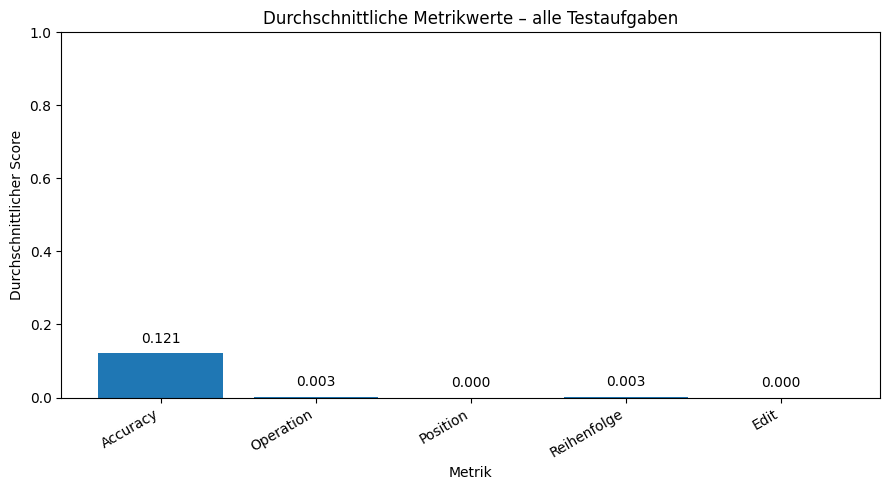


Diagramm gespeichert unter:
/mnt/c/BA/ec/dreamcoder_train_test_pipeline_step_by_step/outputs/train_T_2_train__test_T_2_test__ET_10_TT_10_it_2_MF_20_rec_false_nocons_false/step08_summarize_results/metric_bar_chart_all_tasks.png

Finale Summary
DreamCoder train/test summary

Train tasks used: 150
Test tasks used: 99
Iterations: 2
Enumeration timeout: 10.0
Testing timeout: 10.0
Recognition model enabled: False
Grammar consolidation disabled: False

Test tasks: 99
Solved test tasks: 12
Accuracy: 0.121212
Trivial solutions: 0
Normalized exact matches: 0
Abstract exact matches: 0

Normalized metrics over all test tasks:
  operation_score: 0.002525
  position_score: 0.000000
  order_score: 0.002525
  edit_score: 0.000000
Normalized metrics over solved test tasks only:
  operation_score: 0.020833
  position_score: 0.000000
  order_score: 0.020833
  edit_score: 0.000000

Abstract metrics over all test tasks:
  operation_score: 0.010943
  position_score: 0.003367
  order_score: 0.010943
  edit_

In [16]:
# ============================================================
# Letzte Zelle: Diagramm der finalen Metriken erzeugen
# Robuste Version: ignoriert abgebrochene Läufe
# ============================================================

from pathlib import Path
import json
import matplotlib.pyplot as plt

try:
    ROOT
except NameError:
    ROOT = Path.cwd()

outputs_dir = ROOT / "outputs"

if not outputs_dir.exists():
    raise FileNotFoundError(f"Output-Ordner nicht gefunden: {outputs_dir}")

# Nur Läufe verwenden, bei denen step07_metrics_summary.json existiert
valid_runs = []

for run_dir in outputs_dir.iterdir():
    if not run_dir.is_dir():
        continue

    metrics_file = run_dir / "step07_calculate_metrics" / "step07_metrics_summary.json"

    if metrics_file.exists():
        valid_runs.append(run_dir)

if not valid_runs:
    raise FileNotFoundError(
        "Kein vollständiger Lauf mit step07_metrics_summary.json gefunden."
    )

# Neuesten vollständigen Lauf nehmen
latest_run = sorted(
    valid_runs,
    key=lambda p: p.stat().st_mtime,
    reverse=True
)[0]

metrics_path = latest_run / "step07_calculate_metrics" / "step07_metrics_summary.json"
summary_path = latest_run / "step08_summarize_results" / "step08_summary.txt"

print("Verwendeter vollständiger Ergebnisordner:")
print(latest_run)
print()

with open(metrics_path, "r", encoding="utf-8") as f:
    metrics = json.load(f)

# Werte robust lesen
accuracy = (
    metrics.get("test_accuracy")
    or metrics.get("accuracy")
    or metrics.get("Accuracy")
    or 0.0
)

operation_score = (
    metrics.get("normalized_operation_score_mean")
    or metrics.get("operation_score_mean")
    or 0.0
)

position_score = (
    metrics.get("normalized_position_score_mean")
    or metrics.get("position_score_mean")
    or 0.0
)

order_score = (
    metrics.get("normalized_order_score_mean")
    or metrics.get("order_score_mean")
    or 0.0
)

edit_score = (
    metrics.get("normalized_edit_score_mean")
    or metrics.get("edit_score_mean")
    or 0.0
)

labels = [
    "Accuracy",
    "Operation",
    "Position",
    "Reihenfolge",
    "Edit"
]

values = [
    accuracy,
    operation_score,
    position_score,
    order_score,
    edit_score
]

plt.figure(figsize=(9, 5))
bars = plt.bar(labels, values)

plt.ylim(0, 1)
plt.ylabel("Durchschnittlicher Score")
plt.xlabel("Metrik")
plt.title("Durchschnittliche Metrikwerte – alle Testaufgaben")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plot_path = latest_run / "step08_summarize_results" / "metric_bar_chart_all_tasks.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")

plt.show()

print()
print("Diagramm gespeichert unter:")
print(plot_path)

if summary_path.exists():
    print()
    print("=" * 80)
    print("Finale Summary")
    print("=" * 80)
    print(summary_path.read_text(encoding="utf-8"))

## Optional: mittlerer Lauf

Erst ausführen, wenn der kleine Lauf funktioniert. Ändere oben die Konfiguration auf z. B.:

```python
MAX_TRAIN_TASKS = 300
DREAMCODER_TIMEOUT = 15
DREAMCODER_TESTING_TIMEOUT = 15
DREAMCODER_ITERATIONS = 2
DREAMCODER_FRONTIER_SIZE = 30
DREAMCODER_USE_RECOGNITION = "true"
DREAMCODER_NO_CONSOLIDATION = "true"
```

Dann Notebook-Kernel neu starten und wieder ab Schritt 0 ausführen.
